# B1 — Direct Multi-Step XGBoost / HGB — **Perfect Weather Forecast**

## Executive Summary
Identical to notebook `01_baseline_xgboost.ipynb` **except** meteorological features
(`TEMP`, `WIND_SPEED`, `PRESS_SEA`, `HUMIDITY`, `DEW_POINT`, `RAIN_6H`, `SUNSHINE`, `blh`)
are taken at time **t+h** instead of **t**, simulating a perfect NWP forecast.
All other features (PM2.5 lags, cyclical time, neighbors, HYSPLIT) are unchanged.

**Weather mode:** `"perfect_forecast"` — `MET_COLS` shifted by `-h` so row `t`
carries the weather measured at `t+h`. This is the standard setup in the
academic AQ-forecasting literature (Liao et al., 2023).

**Expected effect:** Improved R² at h ≥ 6 where current weather has drifted
substantially from future weather. h=1 results should be nearly identical to A1.

In [5]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from src.config import (
    DATA_PATH, TARGET, HORIZONS, N_OPTUNA_TRIALS,
    MODEL_DIR, FIGURES_DIR, RESULTS_DIR
)
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix, WEATHER_MODE_PERFECT
from src.models.baseline_gbm import train_direct_multistep, predict_all_horizons
from src.evaluation import compute_metrics, plot_horizon_metrics, plot_actual_vs_predicted, shap_analysis, comparison_table
from src.utils import ensure_dirs, set_seed

WEATHER_MODE = WEATHER_MODE_PERFECT   # ← only difference from notebook 01

set_seed(42)
ensure_dirs(MODEL_DIR, FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print(f'Weather mode: {WEATHER_MODE}')

Weather mode: perfect_forecast


## 1. Load and Split Data

In [6]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)
print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')

16:43:46 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
16:43:46 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
16:43:46 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
16:43:46 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
16:43:46 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Train: 43,824 rows | Test: 8,784 rows


## 2. Feature Matrix Preview (h=24)
Met columns at t+24; all other features still at t.

In [7]:
X_preview, y_preview = build_feature_matrix(train_df, horizon=24, weather_mode=WEATHER_MODE)
print(f'Feature matrix shape: {X_preview.shape}')
print(f'Feature names ({len(X_preview.columns)}):')
for i, col in enumerate(X_preview.columns):
    print(f'  {i:2d}. {col}')

16:43:46 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=perfect_forecast
16:43:46 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -24 hours
16:43:46 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:43:46 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:43:46 | src.feature_engineering | INFO |   X: (38057, 45) | y mean=17.38, y std=12.67


Feature matrix shape: (38057, 45)
Feature names (45):
   0. TEMP
   1. WIND_SPEED
   2. PRESS_SEA
   3. HUMIDITY
   4. DEW_POINT
   5. RAIN_6H
   6. SUNSHINE
   7. blh
   8. lon_48
   9. lat_48
  10. dist_48_straight
  11. dist_48_total
  12. ratio_48
  13. lon_24
  14. lat_24
  15. dist_24_straight
  16. dist_24_total
  17. ratio_24
  18. hour_sin
  19. hour_cos
  20. month_sin
  21. month_cos
  22. day_sin
  23. day_cos
  24. is_weekend
  25. pm25_now
  26. pm25_lag_24h
  27. pm25_lag_48h
  28. rolling_mean_24h
  29. rolling_max_24h
  30. trend_24h
  31. MzOtwoBrzozo_lag1h
  32. MzWarWokalna_lag1h
  33. MzWarAlNiepo_lag1h
  34. MzLegZegrzyn_lag1h
  35. MzPiasPulask_lag1h
  36. MzWarBajkowa_lag1h
  37. dir_48_L
  38. dir_48_N
  39. dir_48_S
  40. dir_48_W
  41. dir_24_L
  42. dir_24_N
  43. dir_24_S
  44. dir_24_W


## 3. Train XGBoost — All 24 Horizons

In [8]:
QUICK_TEST = True
n_trials = 5 if QUICK_TEST else N_OPTUNA_TRIALS

print(f'Training XGBoost [perfect_forecast] with n_trials={n_trials} per horizon...')
xgb_models = train_direct_multistep(
    train_df, model_type='xgb', n_trials=n_trials, save_models=True,
    weather_mode=WEATHER_MODE
)
print('XGBoost training complete.')

16:43:46 | src.models.baseline_gbm | INFO | ============================================================
16:43:46 | src.models.baseline_gbm | INFO | Direct multi-step training: XGB | 24 horizons | 5 Optuna trials each | weather=perfect_forecast
16:43:46 | src.models.baseline_gbm | INFO | ============================================================
16:43:46 | src.models.baseline_gbm | INFO | [1/24] Starting horizon h=1 ...
16:43:46 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast
16:43:47 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -1 hours
16:43:47 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:43:47 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:43:47 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69


Training XGBoost [perfect_forecast] with n_trials=5 per horizon...


16:43:47 | src.models.baseline_gbm | INFO |   X=(38271, 45)  y_mean=17.38  y_std=12.69
16:43:47 | src.models.baseline_gbm | INFO |   Optuna search: XGB | horizon=+1h | 5 trials | 5-fold TimeSeriesSplit
16:44:06 | src.models.baseline_gbm | INFO |   trial 1/5 — best CV MAE so far: 1.8889
16:44:21 | src.models.baseline_gbm | INFO |   trial 2/5 — best CV MAE so far: 1.8889
16:44:27 | src.models.baseline_gbm | INFO |   trial 3/5 — best CV MAE so far: 1.8889
16:44:32 | src.models.baseline_gbm | INFO |   trial 4/5 — best CV MAE so far: 1.8889
16:44:36 | src.models.baseline_gbm | INFO |   trial 5/5 — best CV MAE so far: 1.8534
16:44:36 | src.models.baseline_gbm | INFO |   Best h=1: CV MAE=1.8534 in 49s | params={'learning_rate': 0.04446862319918233, 'n_estimators': 141, 'max_depth': 6, 'min_child_weight': 12, 'reg_lambda': 0.06505159298527952, 'subsample': 0.9795542149013333, 'colsample_bytree': 0.9862528132298237}
16:44:37 | src.models.baseline_gbm | INFO | [1/24] h=1 done in 51s | elapsed=51

XGBoost training complete.


## 4. Train HistGradientBoosting — All 24 Horizons

In [9]:
print(f'Training HGB [perfect_forecast] with n_trials={n_trials} per horizon...')
hgb_models = train_direct_multistep(
    train_df, model_type='hgb', n_trials=n_trials, save_models=True,
    weather_mode=WEATHER_MODE
)
print('HGB training complete.')

17:07:29 | src.models.baseline_gbm | INFO | ============================================================
17:07:29 | src.models.baseline_gbm | INFO | Direct multi-step training: HGB | 24 horizons | 5 Optuna trials each | weather=perfect_forecast
17:07:29 | src.models.baseline_gbm | INFO | ============================================================
17:07:29 | src.models.baseline_gbm | INFO | [1/24] Starting horizon h=1 ...
17:07:29 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast
17:07:29 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -1 hours
17:07:29 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
17:07:29 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns


Training HGB [perfect_forecast] with n_trials=5 per horizon...


17:07:29 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69
17:07:29 | src.models.baseline_gbm | INFO |   X=(38271, 45)  y_mean=17.38  y_std=12.69
17:07:29 | src.models.baseline_gbm | INFO |   Optuna search: HGB | horizon=+1h | 5 trials | 5-fold TimeSeriesSplit
17:07:45 | src.models.baseline_gbm | INFO |   trial 1/5 — best CV MAE so far: 1.8772
17:08:13 | src.models.baseline_gbm | INFO |   trial 2/5 — best CV MAE so far: 1.8299
17:08:16 | src.models.baseline_gbm | INFO |   trial 3/5 — best CV MAE so far: 1.8299
17:08:26 | src.models.baseline_gbm | INFO |   trial 4/5 — best CV MAE so far: 1.8299
17:08:33 | src.models.baseline_gbm | INFO |   trial 5/5 — best CV MAE so far: 1.8299
17:08:33 | src.models.baseline_gbm | INFO |   Best h=1: CV MAE=1.8299 in 65s | params={'learning_rate': 0.006194745024628934, 'max_iter': 880, 'max_depth': 6, 'min_samples_leaf': 37, 'l2_regularization': 0.020584494295802447, 'max_bins': 250}
17:08:42 | src.models.baseline_gbm | INFO

HGB training complete.


## 5. Evaluate on Test Set (2024)

In [10]:
results = {'XGBoost_pfx': {}, 'HGB_pfx': {}}

for h in tqdm(HORIZONS, desc='Evaluating horizons'):
    X_test_h, y_test_h = build_feature_matrix(test_df, horizon=h, weather_mode=WEATHER_MODE)

    results['XGBoost_pfx'][h] = compute_metrics(y_test_h.values, xgb_models[h].predict(X_test_h.values))
    results['HGB_pfx'][h]     = compute_metrics(y_test_h.values, hgb_models[h].predict(X_test_h.values))

print('Evaluation complete.')
for model_name in results:
    print(f'\n{model_name}:')
    for h in [1, 6, 12, 24]:
        m = results[model_name][h]
        print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

Evaluating horizons:   0%|          | 0/24 [00:00<?, ?it/s]

17:50:49 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast
17:50:49 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -1 hours
17:50:49 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
17:50:49 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
17:50:49 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
17:50:49 | src.feature_engineering | INFO | build_feature_matrix | horizon=2 | weather_mode=perfect_forecast
17:50:50 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -2 hours
17:50:50 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
17:50:50 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
17:50:50 | src.feature_engineering | INFO |   X: (7800, 45) | y mean=12.62, y std=8.41
17:50:50 | src

Evaluation complete.

XGBoost_pfx:
  h= 1: MAE=1.140  RMSE=1.841  R²=0.952
  h= 6: MAE=3.094  RMSE=4.541  R²=0.706
  h=12: MAE=3.864  RMSE=5.436  R²=0.579
  h=24: MAE=4.178  RMSE=5.856  R²=0.513

HGB_pfx:
  h= 1: MAE=1.133  RMSE=1.839  R²=0.952
  h= 6: MAE=3.060  RMSE=4.472  R²=0.715
  h=12: MAE=3.873  RMSE=5.516  R²=0.566
  h=24: MAE=4.116  RMSE=5.845  R²=0.515


## 6. Comparison: Current Weather (A1) vs Perfect Forecast (B1)

17:50:58 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\B1_vs_A1_mae.png


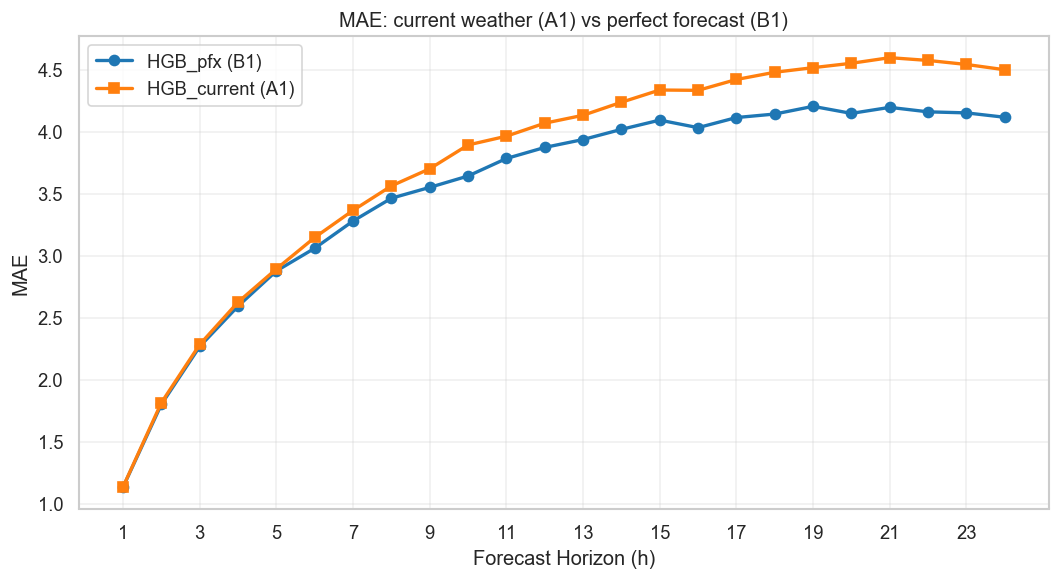

17:50:58 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\B1_vs_A1_r2.png


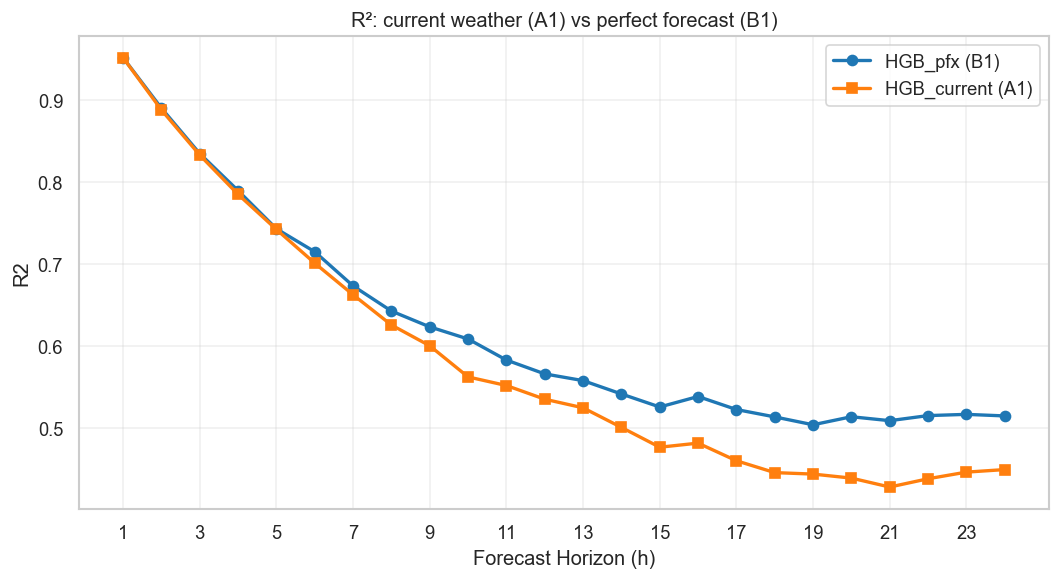

In [11]:
arch1_path = RESULTS_DIR / 'arch1_metrics.csv'
compare = {'HGB_pfx (B1)': results['HGB_pfx']}
if arch1_path.exists():
    arch1_df = pd.read_csv(arch1_path)
    results_hgb_cur = {}
    for _, row in arch1_df[arch1_df['Model'] == 'Arch1_HGB'].iterrows():
        results_hgb_cur[int(row['Horizon'])] = {
            'MAE': row['MAE'], 'RMSE': row['RMSE'], 'R2': row['R2'],
            'MBE': row['MBE'], 'IA': row['IA']
        }
    compare['HGB_current (A1)'] = results_hgb_cur

fig = plot_horizon_metrics(compare, metric='MAE',
                           save_path=FIGURES_DIR / 'B1_vs_A1_mae.png')
plt.title('MAE: current weather (A1) vs perfect forecast (B1)')
plt.show()

fig = plot_horizon_metrics(compare, metric='R2',
                           save_path=FIGURES_DIR / 'B1_vs_A1_r2.png')
plt.title('R²: current weather (A1) vs perfect forecast (B1)')
plt.show()

## 7. Actual vs Predicted Time Series (h=24, Winter 2024)

17:50:58 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=perfect_forecast
17:50:58 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -24 hours
17:50:58 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
17:50:58 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
17:50:59 | src.feature_engineering | INFO |   X: (7766, 45) | y mean=12.60, y std=8.39


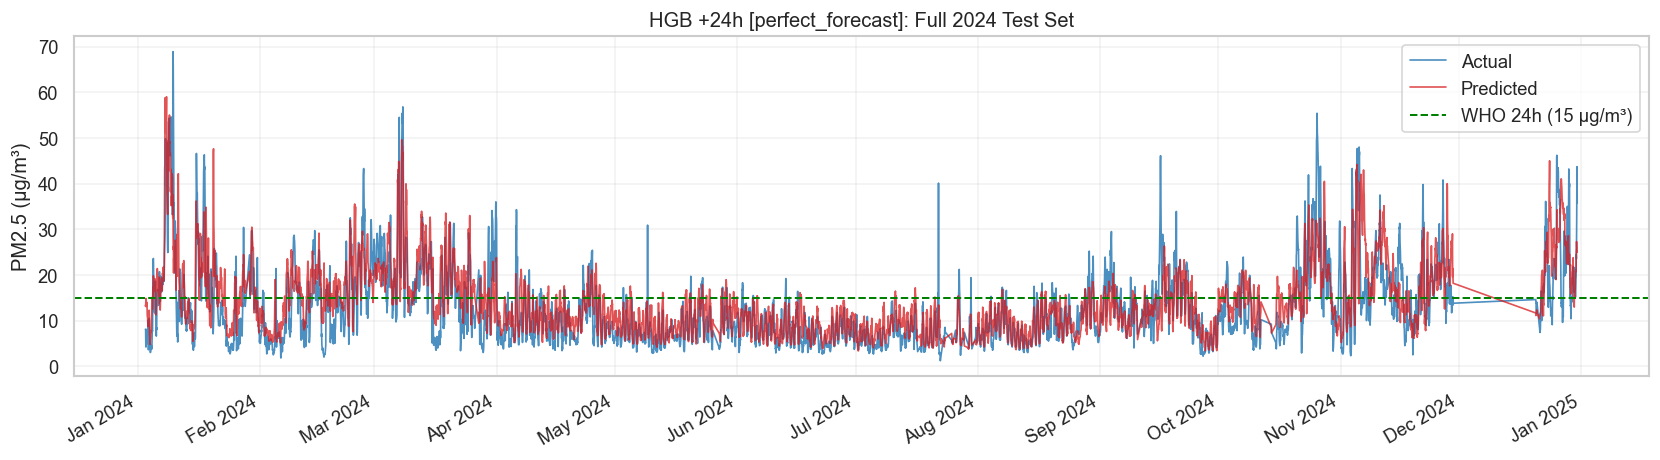

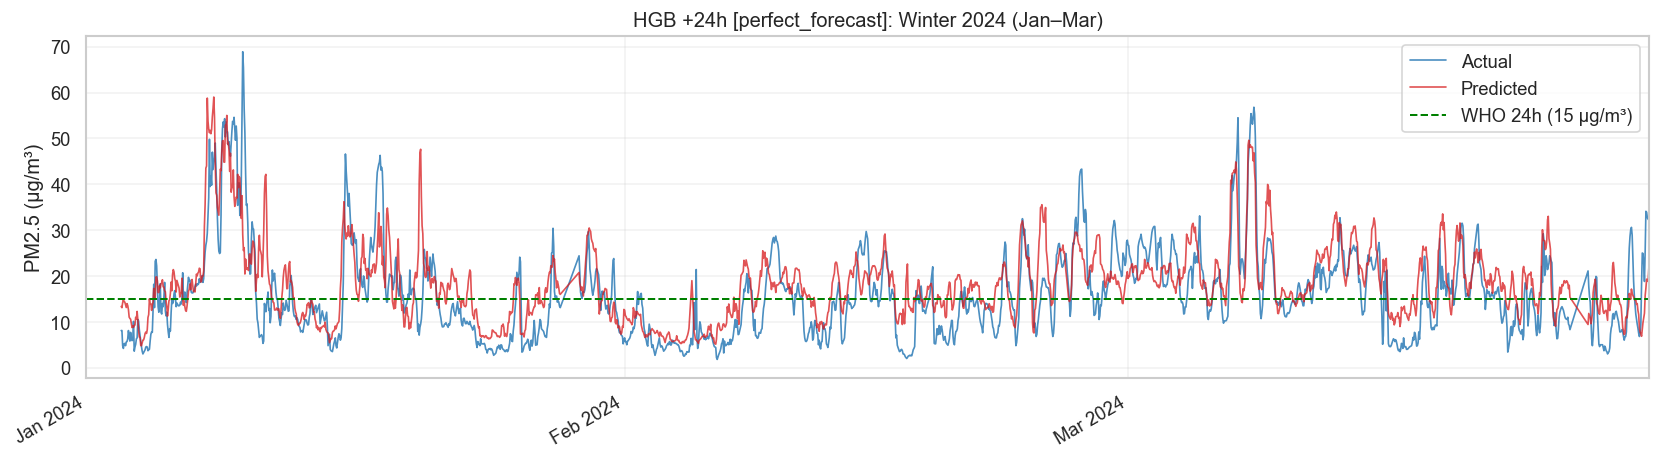

In [12]:
X_test_24, y_test_24 = build_feature_matrix(test_df, horizon=24, weather_mode=WEATHER_MODE)
hgb_pred_24 = hgb_models[24].predict(X_test_24.values)

fig = plot_actual_vs_predicted(
    y_test_24, hgb_pred_24,
    title='HGB +24h [perfect_forecast]: Full 2024 Test Set',
    save_path=FIGURES_DIR / 'B1_hgb_full_2024.png'
)
plt.show()

fig = plot_actual_vs_predicted(
    y_test_24, hgb_pred_24,
    title='HGB +24h [perfect_forecast]: Winter 2024 (Jan–Mar)',
    zoom_period=('2024-01-01', '2024-03-31'),
    save_path=FIGURES_DIR / 'B1_hgb_winter2024.png'
)
plt.show()

## 8. SHAP Feature Importance

In [13]:
for h in [1, 6, 12, 24]:
    X_test_h, _ = build_feature_matrix(test_df, horizon=h, weather_mode=WEATHER_MODE)
    inner_model = xgb_models[h].regressor_
    shap_analysis(
        inner_model, X_test_h, X_test_h.columns.tolist(),
        save_dir=FIGURES_DIR,
        title_suffix=f'B1_XGB_h{h}'
    )

17:51:00 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=perfect_forecast
17:51:00 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -1 hours
17:51:00 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
17:51:00 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
17:51:00 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
17:51:03 | src.evaluation | INFO | SHAP plots saved to D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures
17:51:03 | src.feature_engineering | INFO | build_feature_matrix | horizon=6 | weather_mode=perfect_forecast
17:51:03 | src.feature_engineering | INFO | perfect_forecast mode: shifted 8 MET_COLS by -6 hours
17:51:03 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
17:51:03 | src.feature_engineering | INFO | Retaining

## 9. Save Results

In [14]:
rows = []
for model_name, h_metrics in results.items():
    for h, metrics in h_metrics.items():
        rows.append({'Model': f'B1_{model_name}', 'Horizon': h, **metrics})

arch_b1_df = pd.DataFrame(rows)
arch_b1_df.to_csv(RESULTS_DIR / 'B1_metrics.csv', index=False)
print('Saved B1_metrics.csv')

tbl = comparison_table({'XGBoost_pfx': results['XGBoost_pfx'], 'HGB_pfx': results['HGB_pfx']})
print('\nKey horizon comparison (perfect_forecast):')
print(tbl.to_string(float_format='%.3f'))

Saved B1_metrics.csv

Key horizon comparison (perfect_forecast):
                      MAE  RMSE    R2   MBE    IA
Model       Horizon                              
HGB_pfx     1       1.133 1.839 0.952 0.043 0.988
            6       3.060 4.472 0.715 0.813 0.919
            12      3.873 5.516 0.566 1.460 0.876
            24      4.116 5.845 0.515 1.425 0.852
XGBoost_pfx 1       1.140 1.841 0.952 0.048 0.988
            6       3.094 4.541 0.706 0.749 0.916
            12      3.864 5.436 0.579 1.495 0.879
            24      4.178 5.856 0.513 1.661 0.856
